In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score,roc_curve
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.svm import SVR, SVC
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

In [3]:
#Neural network realted packages deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('Libraries imported. TensorFlow version:', tf.__version__)

Libraries imported. TensorFlow version: 2.19.0


In [5]:
#load data
# California Housing (Regression)
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)
df_h = housing.frame.copy()
df_h.head()
# PIMA Indians Diabetes (Classification)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols =["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age","Outcome"]
df_p = pd.read_csv(url, names=cols)
df_p.head()

#no class

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
# --- California Housing preprocessing ---
X_h = df_h.drop(columns=['MedHouseVal'])
y_h = df_h['MedHouseVal']

# Train-test split
Xh_train, Xh_test, yh_train, yh_test = train_test_split(X_h, y_h, test_size=0.2, random_state=42)

# Scale features
scaler_h = StandardScaler()
Xh_train_scaled = scaler_h.fit_transform(Xh_train)
Xh_test_scaled = scaler_h.transform(Xh_test)

print('California: train shape', Xh_train.shape, 'test shape', Xh_test.shape)

California: train shape (16512, 8) test shape (4128, 8)


In [7]:
# --- PIMA preprocessing ---
df_p_clean = df_p.copy()

# In PIMA, zeros in certain columns indicate missing values
cols_missing = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df_p_clean[cols_missing] = df_p_clean[cols_missing].replace(0, pd.NA)

# Impute with median
for c in cols_missing:
  df_p_clean[c] = df_p_clean[c].fillna(df_p_clean[c].median())

X_p = df_p_clean.drop(columns=['Outcome'])
y_p = df_p_clean['Outcome']

Xp_train, Xp_test, yp_train, yp_test = train_test_split(X_p, y_p, test_size=0.2, random_state=42,
stratify=y_p)

scaler_p = StandardScaler()
Xp_train_scaled = scaler_p.fit_transform(Xp_train)
Xp_test_scaled = scaler_p.transform(Xp_test)

print('PIMA: train shape', Xp_train.shape, 'test shape', Xp_test.shape)
print('Class distribution (train):\n', yp_train.value_counts(normalize=True))

PIMA: train shape (614, 8) test shape (154, 8)
Class distribution (train):
 Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64


In [8]:
def regression_metrics(y_true, y_pred):
  mse = mean_squared_error(y_true, y_pred)
  rmse = np.sqrt(mse) # <-- manual RMSE
  mae = mean_absolute_error(y_true, y_pred)
  r2 = r2_score(y_true, y_pred)
  return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

results_reg = {}

# 4.1 Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(Xh_train_scaled, yh_train)
y_lr = lr.predict(Xh_test_scaled)

results_reg['LinearRegression'] = regression_metrics(yh_test, y_lr)
print(results_reg['LinearRegression'])

{'RMSE': np.float64(0.7455813830127763), 'MAE': 0.5332001304956565, 'R2': 0.575787706032451}


In [9]:
# 4.2 Decision Tree Regressor
dtr = DecisionTreeRegressor(max_depth=6, random_state=42)
dtr.fit(Xh_train_scaled, yh_train)
y_dtr = dtr.predict(Xh_test_scaled)
results_reg['DecisionTreeRegressor'] = regression_metrics(yh_test, y_dtr)
results_reg['DecisionTreeRegressor']

{'RMSE': np.float64(0.7051835278617654),
 'MAE': 0.5008044131156354,
 'R2': 0.6205125146233951}

In [10]:
# 4.3 Random Forest Regressor
rfr = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rfr.fit(Xh_train_scaled, yh_train)
y_rfr = rfr.predict(Xh_test_scaled)
results_reg['RandomForestRegressor'] = regression_metrics(yh_test, y_rfr)
results_reg['RandomForestRegressor']

{'RMSE': np.float64(0.5443328206986048),
 'MAE': 0.36628865979805514,
 'R2': 0.7738887441938533}

In [11]:
# 4.4 Support Vector Regressor (SVR)
# Note: SVR can be slow on large datasets; we demonstrate on a subset for speed.
svr = SVR(C=1.0, kernel='rbf')
svr.fit(Xh_train_scaled[:2000], yh_train[:2000])
y_svr = svr.predict(Xh_test_scaled)
results_reg['SVR_subset_fit'] = regression_metrics(yh_test, y_svr)
results_reg['SVR_subset_fit']

{'RMSE': np.float64(0.640945853421283),
 'MAE': 0.43409372083776865,
 'R2': 0.686501242101216}

In [12]:
# 4.5 Neural Network (Keras) for Regression
tf.random.set_seed(42)
model_reg = keras.Sequential([
layers.Input(shape=(Xh_train_scaled.shape[1],)),
layers.Dense(128, activation='relu'),
layers.Dropout(0.2),
layers.Dense(64, activation='relu'),
layers.Dense(1)
])
model_reg.compile(optimizer='adam', loss='mse', metrics=['mae'])
es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model_reg.fit(Xh_train_scaled, yh_train, validation_split=0.15, epochs=100, batch_size=32,callbacks=[es], verbose=0)
y_keras = model_reg.predict(Xh_test_scaled).ravel()
results_reg['Keras_DNN'] = regression_metrics(yh_test, y_keras)
results_reg['Keras_DNN']

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


{'RMSE': np.float64(0.5343581551192964),
 'MAE': 0.3645144365781823,
 'R2': 0.7820996019686871}

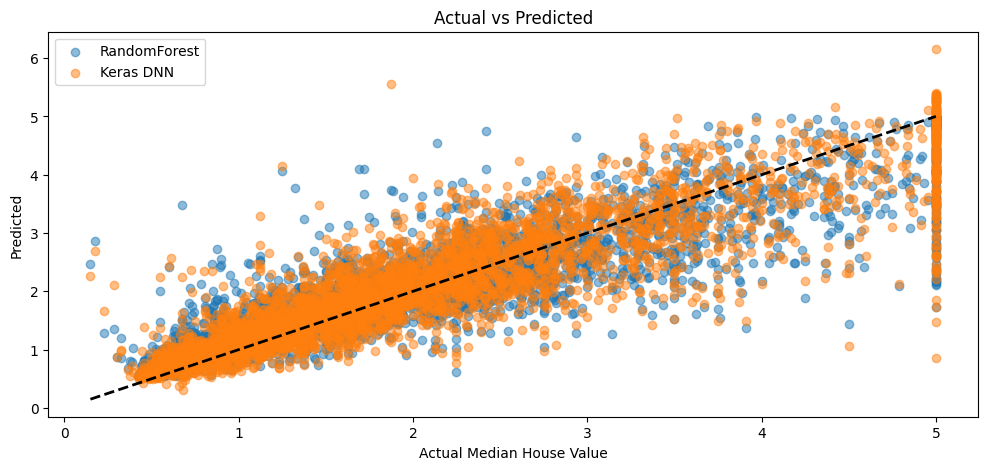

In [13]:
# Show regression results
import pandas as pd
pd.DataFrame(results_reg).T
# Regression: Actual vs Predicted (Random Forest & Keras)
plt.figure(figsize=(12,5))
plt.scatter(yh_test, y_rfr, alpha=0.5, label='RandomForest')
plt.scatter(yh_test, y_keras, alpha=0.5, label='Keras DNN')
plt.plot([yh_test.min(), yh_test.max()], [yh_test.min(), yh_test.max()], 'k--', lw=2)
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted')
plt.legend()
plt.title('Actual vs Predicted')
plt.show()

In [ ]:
# 5.1 Logistic Regression
logr = LogisticRegression(max_iter=1000)
logr.fit(Xp_train_scaled, yp_train)
yp_lr = logr.predict(Xp_test_scaled)
results_clf['LogisticRegression'] = {'accuracy': accuracy_score(yp_test, yp_lr),'roc_auc': roc_auc_score(yp_test, logr.predict_proba(Xp_test_scaled)[:,1])
}
results_clf['LogisticRegression']

In [ ]:
# 5.2 Decision Tree Classifier
dtc = DecisionTreeClassifier(max_depth=6, random_state=42)
dtc.fit(Xp_train_scaled, yp_train)
yp_dtc = dtc.predict(Xp_test_scaled)
results_clf['DecisionTree'] = {
'accuracy': accuracy_score(yp_test, yp_dtc),
'roc_auc': roc_auc_score(yp_test, dtc.predict_proba(Xp_test_scaled)[:,1])
}
results_clf['DecisionTree']

In [ ]:
# 5.3 Random Forest Classifier
rfc = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rfc.fit(Xp_train_scaled, yp_train)
yp_rfc = rfc.predict(Xp_test_scaled)
results_clf['RandomForest'] = {
'accuracy': accuracy_score(yp_test, yp_rfc),
'roc_auc': roc_auc_score(yp_test, rfc.predict_proba(Xp_test_scaled)[:,1])
}
results_clf['RandomForest']

In [ ]:
# 5.4 SVM (with probability for ROC)
svc = SVC(kernel='rbf', probability=True)
svc.fit(Xp_train_scaled, yp_train)
yp_svc = svc.predict(Xp_test_scaled)
results_clf['SVM'] = {
'accuracy': accuracy_score(yp_test, yp_svc),
'roc_auc': roc_auc_score(yp_test, svc.predict_proba(Xp_test_scaled)[:,1])
}
results_clf['SVM']

In [ ]:
# 5.5 Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(Xp_train_scaled, yp_train)
yp_gnb = gnb.predict(Xp_test_scaled)
results_clf['GaussianNB'] = {
'accuracy': accuracy_score(yp_test, yp_gnb),
'roc_auc': roc_auc_score(yp_test, gnb.predict_proba(Xp_test_scaled)[:,1])
}
results_clf['GaussianNB']

In [ ]:
# 5.6 Keras Neural Network for Classification
tf.random.set_seed(42)
model_clf = keras.Sequential([
layers.Input(shape=(Xp_train_scaled.shape[1],)),
layers.Dense(64, activation='relu'),
layers.Dropout(0.2),
layers.Dense(32, activation='relu'),
layers.Dense(1, activation='sigmoid')
])
model_clf.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
es2 = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_clf = model_clf.fit(Xp_train_scaled, yp_train, validation_split=0.15, epochs=100, batch_size=32,
callbacks=[es2], verbose=0)

yp_keras_prob = model_clf.predict(Xp_test_scaled).ravel()
yp_keras = (yp_keras_prob > 0.5).astype(int)

results_clf['Keras_DNN'] = {
'accuracy': accuracy_score(yp_test, yp_keras),
'roc_auc': roc_auc_score(yp_test, yp_keras_prob)
}
results_clf['Keras_DNN']

# Show classification results
pd.DataFrame(results_clf).T

# ROC Curves
plt.figure(figsize=(8,6))
models_for_roc = {
'Logistic': (logr, Xp_test_scaled),
'RandomForest': (rfc, Xp_test_scaled),
'SVM': (svc, Xp_test_scaled),
'Keras': (model_clf, Xp_test_scaled)
}

for name, (m, Xtest) in models_for_roc.items():
if name == 'Keras':
probs = model_clf.predict(Xtest).ravel()
else:
probs = m.predict_proba(Xtest)[:,1]
fpr, tpr, _ = roc_curve(yp_test, probs)
auc = roc_auc_score(yp_test, probs)
plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

#modify tu bole skip